In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.inspection import permutation_importance

Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

In [2]:
# --- 1. & 2. DATA COLLECTION & PRE-PROCESSING ---
df = pd.read_csv('../data/v0/Final_DataSet_All.csv')

filtered = df.loc[df['Time'] == 'FT'].copy()
conditions = [(filtered['Home_Score'] > filtered['Away_Score']),
              (filtered['Away_Score'] > filtered['Home_Score']),
              (filtered['Home_Score'] == filtered['Away_Score'])]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
match_outcome_dict = dict(zip(filtered['Game_ID'], filtered['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(match_outcome_dict)

df_filtered = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_filtered['Time'] = df_filtered['Time'].apply(eval) 

# Balanced Feature Engineering
df_filtered['Score_Diff'] = df_filtered['Home_Score'] - df_filtered['Away_Score']
df_filtered['Total_Goals'] = df_filtered['Home_Score'] + df_filtered['Away_Score']
df_filtered['Home_Score_Log'] = np.log1p(df_filtered['Home_Score'])
df_filtered['Away_Score_Log'] = np.log1p(df_filtered['Away_Score'])

EDA

In [3]:
# df_filtered.describe()
df_filtered.describe(include=['object'])

,Game_ID,Matchweek,Game_Type,Team,Match_URL,Event_Type,Player_1,Pos_1,Player_2,Pos_2,Note,Match_Outcomes
count,106598,106598,106598,106598,106598,106598,106598,106598,78813,78813,106598,106598
unique,6310,38,1,2,7155,4,3997,14,4634,15,6,3
top,120230701,4,League,Home,https://fbref.com/en/matches/bc7df752/Bayern-M...,Substitution,Vincenzo Grifo,FW,Kevin Behrens,FW,Neutral Sub,Home_Win
freq,99,3054,106598,54573,42,78813,266,25033,131,16109,60365,48171


Train/Test Split

In [4]:
# --- 3. TRAIN/TEST SPLIT ---
features = ['Time', 'Score_Diff', 'Total_Goals', 'Home_Score_Log', 'Away_Score_Log', 
            'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 
            'Home_Def_Sub_Count', 'Away_Off_Sub_Count', 'Away_Def_Sub_Count']
X = df_filtered[features]
y = df_filtered['Match_Outcomes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

Randomized Search - Find best k value

In [5]:
# --- 4. SMOTE + KNN PIPELINE ---
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)), 
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

param_distributions = {
    'pca__n_components': range(1, X.shape[1] + 1),
    'knn__n_neighbors': range(5, 60),
    'knn__weights': ['distance'], 
    'knn__metric': ['manhattan']
}

random_search = RandomizedSearchCV(
    pipeline, param_distributions=param_distributions, n_iter=20, 
    cv=StratifiedKFold(5), scoring='f1_weighted', random_state=42, refit=True
)
random_search.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'knn__metric': ['manhattan'], 'knn__n_neighbors': range(5, 60), 'knn__weights': ['distance'], 'pca__n_components': range(1, 12)}"
,n_iter,20
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


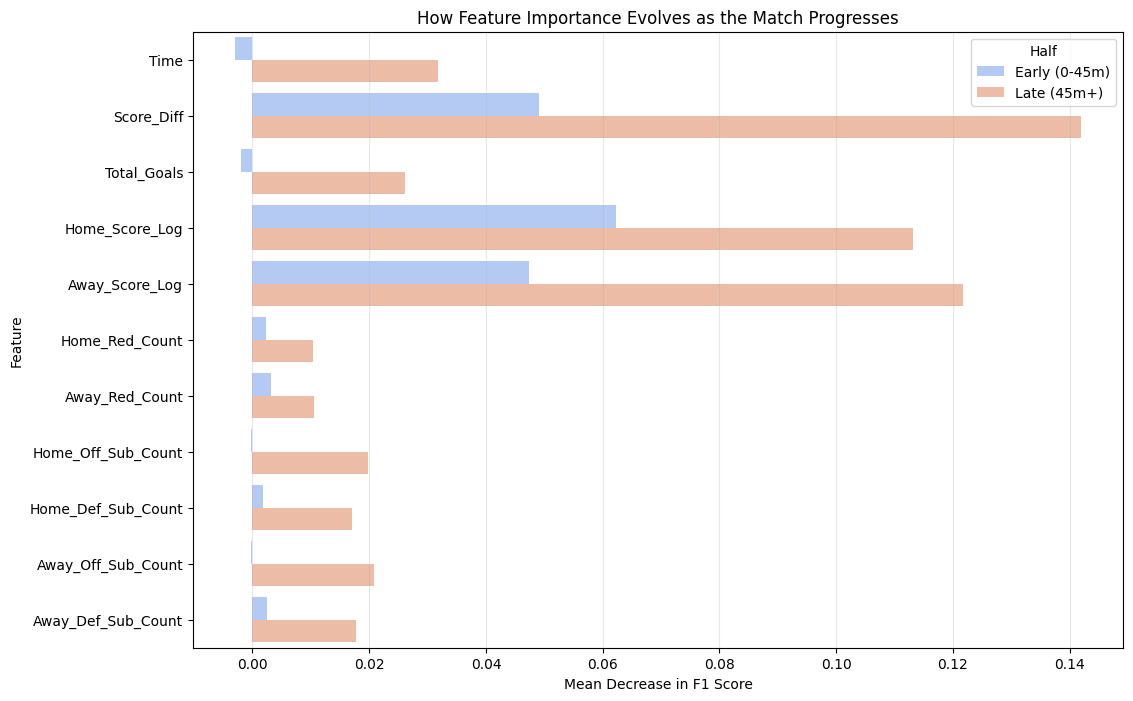

In [6]:
# --- 5. TIME-EVOLVING FEATURE IMPORTANCE ---
# Separate test data into Early (0-45) and Late (45+) segments
early_mask = X_test['Time'] <= 45
late_mask = X_test['Time'] > 45

# Calculate importance for each half
imp_early = permutation_importance(random_search, X_test[early_mask], y_test[early_mask], n_repeats=5, random_state=42)
imp_late = permutation_importance(random_search, X_test[late_mask], y_test[late_mask], n_repeats=5, random_state=42)

# Build comparison dataframe
importance_comp = pd.DataFrame({
    'Feature': features,
    'Early (0-45m)': imp_early.importances_mean,
    'Late (45m+)': imp_late.importances_mean
}).melt(id_vars='Feature', var_name='Half', value_name='Importance')

# Plotting the Comparison
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_comp, x='Importance', y='Feature', hue='Half', palette='coolwarm')
plt.title("How Feature Importance Evolves as the Match Progresses")
plt.xlabel("Mean Decrease in F1 Score")
plt.grid(axis='x', alpha=0.3)
plt.show()

C:\Users\matth\AppData\Local\Temp\ipykernel_8372\4133005735.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_stats = X_test_with_pred.groupby('Time_Bucket', observed=False).apply(


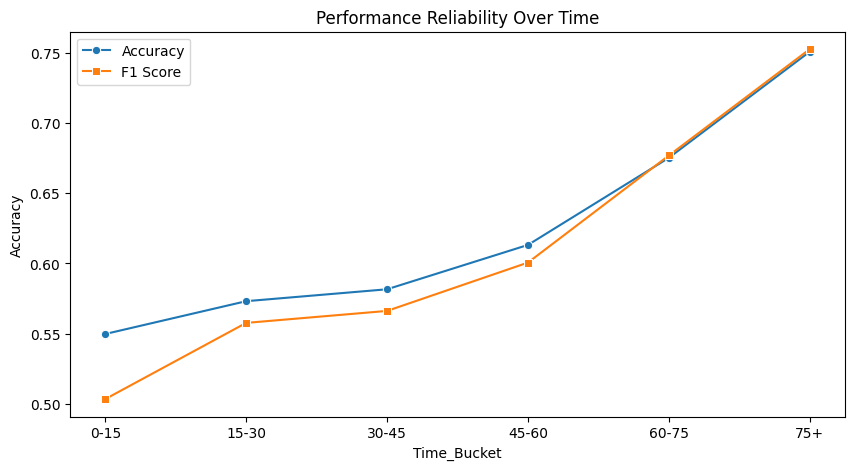


Final Parameters: {'pca__n_components': 6, 'knn__weights': 'distance', 'knn__n_neighbors': 42, 'knn__metric': 'manhattan'}


In [7]:
# --- 6. TIME-BASED ACCURACY ANALYSIS ---
X_test_with_pred = X_test.copy()
X_test_with_pred['Actual'] = y_test
X_test_with_pred['Predicted'] = random_search.predict(X_test)

bins = [0, 15, 30, 45, 60, 75, 100]
labels = ['0-15', '15-30', '30-45', '45-60', '60-75', '75+']
X_test_with_pred['Time_Bucket'] = pd.cut(X_test_with_pred['Time'], bins=bins, labels=labels)

time_stats = X_test_with_pred.groupby('Time_Bucket', observed=False).apply(
    lambda x: pd.Series({
        'Accuracy': accuracy_score(x['Actual'], x['Predicted']),
        'F1_Weighted': f1_score(x['Actual'], x['Predicted'], average='weighted')
    })
).reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=time_stats, x='Time_Bucket', y='Accuracy', marker='o', label='Accuracy')
sns.lineplot(data=time_stats, x='Time_Bucket', y='F1_Weighted', marker='s', label='F1 Score')
plt.title("Performance Reliability Over Time")
plt.show()

print("\nFinal Parameters:", random_search.best_params_)